In [344]:
import numpy as np
import pickle
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.csgraph import laplacian
from sklearn.metrics import mean_squared_error, confusion_matrix, r2_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from math import sqrt
import pycircos
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap
from scipy.io import savemat, loadmat

import torch
import torch.nn as nn

In [345]:
def obs_domain(scaled_limits, scaled_vector):
    min_limit, max_limit = scaled_limits[0], scaled_limits[1]
    unscaled_vector = scaled_vector*(max_limit-min_limit) + min_limit
#     mean_limit, std_limit = scaled_limits[0], scaled_limits[1]
#     unscaled_vector = scaled_vector * std_limit + mean_limit
    return unscaled_vector

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def psnr(true, pred):
    mse = mean_squared_error(true, pred)
    max_pixel_value = np.max(true)
    if mse == 0:
        return float('inf')  # If MSE is zero, PSNR is infinite
    return 20 * np.log10(max_pixel_value / np.sqrt(mse))

In [346]:
habs_paired_data = pd.read_pickle('../data/66 ROIs processing HABS_ADNI/habs_paired_data.pkl')
adni_paired_data = pd.read_pickle('../data/66 ROIs processing HABS_ADNI/adni_paired_data.pkl')
combined_paired_data = pd.concat([habs_paired_data, adni_paired_data])

In [347]:
adnidata_struct = loadmat("../data/Input/ADNI_nonPVC_clean.mat")['data'][0]
adni_clinical = pd.DataFrame(adnidata_struct)
adni_clinical['subjectID'] = adni_clinical['subjectID'].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) else x)
adni_clinical['dob'] = adni_clinical['dob'].apply(
    lambda x: pd.to_datetime(x[0][0], format='%m/%Y') if isinstance(x, (list, np.ndarray)) else pd.NaT
)

In [365]:
clin = adni_clinical.copy()

def scalarize(x):
    # unwrap nested lists/arrays like [[1]] or array([[1]]) -> 1
    while isinstance(x, (list, tuple, np.ndarray, pd.Series)) and len(x) > 0:
        x = x[0]
    # if still array-like with shape (), unwrap
    if isinstance(x, np.ndarray) and x.shape == ():
        x = x.item()
    return x

for col in ["edu", "apoe", "sex", "eth", "tau_tp"]:
    clin[col] = clin[col].apply(scalarize)

clin.head()

,subjectID,tau_pet,tau_tp,edu,dob,sex,eth,mmse,cog,diagn,apoe
0,011_S_0021,"[[[['2018-02-02'], [[1.422 1.313 1.476 1.616 1...",1,18,"DatetimeIndex(['1933-02-01'], dtype='datetime6...",2,2,"[[[['2005-09-28'], [[30]]], [['2006-04-24'], [...","[[[['2005-10-24'], [[0.204]], [[1.804]], [[0.6...","[[[['2005-11-01'], [[1]]], [['2006-04-24'], [[...",0
1,023_S_0031,"[[[['2018-04-24'], [[1.188 1.067 1.469 1.51 0...",2,18,"DatetimeIndex(['1928-01-01'], dtype='datetime6...",2,2,"[[[['2005-10-03'], [[30]]], [['2006-04-18'], [...","[[[['2005-10-24'], [[0.543]], [[2.908]], [[1.0...","[[[['2005-10-24'], [[1]]], [['2006-04-18'], [[...",0
2,067_S_0056,"[[[['2018-02-20'], [[1.417 1.324 1.743 1.854 1...",3,13,"DatetimeIndex(['1936-03-01'], dtype='datetime6...",2,2,"[[[['2005-10-25'], [[28]]], [['2006-07-07'], [...","[[[['2005-12-22'], [[1.69]], [[1.579]], [[0.12...","[[[['2005-12-22'], [[1]]], [['2006-08-10'], [[...",0
3,067_S_0059,"[[[['2017-12-12'], [[1.409 1.238 1.631 1.818 0...",1,13,"DatetimeIndex(['1935-01-01'], dtype='datetime6...",2,2,"[[[['2005-11-09'], [[29]]], [['2006-07-07'], [...","[[[['2005-12-22'], [[0.236]], [[1.191]], [[0.4...","[[[['2006-01-10'], [[1]]], [['2006-08-10'], [[...",0
4,100_S_0069,"[[[['2018-04-03'], [[1.361 1.323 1.84 1.922 1...",4,16,"DatetimeIndex(['1933-01-01'], dtype='datetime6...",1,2,"[[[['2005-12-08'], [[28]]], [['2006-07-11'], [...","[[[['2006-01-17'], [[0.004]], [[0.198]], [[0.3...","[[[['2006-01-17'], [[1]]], [['2006-07-12'], [[...",0


In [390]:
# split = 'test'
# split_data_objects = torch.load(f'../data/66 ROIs processing HABS_ADNI/adni_{split}_data_objects.pt')

split_data_objects = torch.load(f'../data/66 ROIs processing HABS_ADNI/adni_train_data_objects.pt') +torch.load(f'../data/66 ROIs processing HABS_ADNI/adni_val_data_objects.pt') + torch.load(f'../data/66 ROIs processing HABS_ADNI/adni_test_data_objects.pt')

In [391]:
split_demographics = []
for data in split_data_objects:
    subjectid = data.subid
    tp1 = int(data.tps[0])
    age = adni_paired_data[
        (adni_paired_data["Subject ID"]==subjectid) &
        (adni_paired_data["tp1"]==tp1)
    ]["Age1"].values[0]
    
    clin_row = clin[clin["subjectID"]==subjectid]
    sex = clin_row["sex"].values[0]
    edu = clin_row["edu"].values[0]
    eth = clin_row["eth"].values[0]
    apoe = clin_row["apoe"].values[0]
    
    split_demographics.append({
        "Subject ID": subjectid,
        "tp1": tp1,
        "Age": age,
        "Sex": sex,
        "Education": edu,
        "Ethnicity": eth,
        "APOE": apoe
    })
split_demographics = pd.DataFrame(split_demographics)
split_demographics

,Subject ID,tp1,Age,Sex,Education,Ethnicity,APOE
0,021_S_4744,1,77.445585,2,12,2,2
1,129_S_4422,1,76.153320,2,15,2,0
2,129_S_4422,2,77.130732,2,15,2,0
3,007_S_4387,1,82.162902,2,16,2,1
4,007_S_4387,2,83.099247,2,16,2,1
...,...,...,...,...,...,...,...
774,130_S_4817,1,65.689254,1,20,2,2
775,003_S_5154,1,77.845311,2,18,2,1
776,003_S_5154,2,81.601643,2,18,2,1
777,011_S_6465,1,67.019849,1,18,2,0


In [392]:
summary_demographics = {}
summary_demographics["N scans"] = len(split_demographics)
summary_demographics["N unique subjects"] = split_demographics["Subject ID"].nunique()

summary_demographics["Age mean"] = split_demographics["Age"].mean()
summary_demographics["Age std"] = split_demographics["Age"].std()

summary_demographics["Education mean"] = split_demographics["Education"].mean()
summary_demographics["Education std"] = split_demographics["Education"].std()

sex_counts = split_demographics["Sex"].value_counts()
summary_demographics["N_male"]   = sex_counts.get(1, 0)
summary_demographics["N_female"] = sex_counts.get(2, 0)

summary_demographics["APOE_positive"] = (split_demographics["APOE"] == 1).sum()

summary_demographics = pd.DataFrame(summary_demographics, index=[0])
summary_demographics

,N scans,N unique subjects,Age mean,Age std,Education mean,Education std,N_male,N_female,APOE_positive
0,779,462,74.009748,7.427701,16.48267,2.429075,377,402,297


In [ ]:
###

In [618]:
cohort = 'adni'
split = 'test'

# best_train = torch.load(f'../results revision/{cohort}/best_train.pth')
# best_val = torch.load(f'../results revision/{cohort}/best_val.pth')
# best_test = torch.load(f'../results revision/{cohort}/best_test.pth')

# fkpp_savename = f'lat_0.0147_0.0171'
# esm_savename = f'lat_8.804e-5_0.001'

fkpp_savename = f'fkpp_lat_0.00645_0.00738'
esm_savename = f'esm_lat_8.804e-5_0.001'

data_objects = torch.load(f'../data/66 ROIs processing HABS_ADNI/{cohort}_{split}_data_objects.pt')
data_objects = data_objects
pred_no_reg = torch.load(f'../results revision/{cohort}/no_reg_best_{split}.pth')
pred_fkpp = torch.load(f'../results revision/{cohort}/{fkpp_savename}_best_{split}.pth')
pred_esm = torch.load(f'../results revision/{cohort}/{esm_savename}_best_{split}.pth')
paired_data = adni_paired_data.copy()

In [619]:
### habs validation
# habs_train_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/habs_train_data_objects.pt')
# habs_val_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/habs_val_data_objects.pt')
# habs_test_data = torch.load(f'../data/66 ROIs processing HABS_ADNI/habs_test_data_objects.pt')
# habs_data = habs_train_data + habs_val_data + habs_test_data
# data_objects = habs_data
# pred_no_reg = torch.load(f'../results revision/{cohort}/no_reg_best_habsval.pth')
# pred_fkpp = torch.load(f'../results revision/{cohort}/fkpp_best_habsval.pth')
# pred_esm = torch.load(f'../results revision/{cohort}/esm_best_habsval.pth')
# paired_data = habs_paired_data.copy()

In [620]:
len(data_objects)

123

In [621]:
## TRYING

In [622]:
regularizers_comparison = []

for index in range(len(data_objects)):
    subid = data_objects[index].subid
    cohort = data_objects[index].cohort
    tp1, tp2 = data_objects[index].tps
    row_idx = paired_data.index[(paired_data['Subject ID'] == subid) & 
                            (paired_data['tp1'] == tp1) & (paired_data['tp2'] == tp2)]
    row = paired_data.loc[row_idx]
    limits = row['Scale Limits'].values[0]
    
    baseline = row['Tau tp1'].values[0]
    followup = row['Annualized Tau tp2'].values[0]
#     pred = obs_domain(limits, sample_result.detach().flatten() + row['Scaled Tau tp1'].values[0])
    
    no_reg = obs_domain(limits, 
                        pred_no_reg[index].detach().flatten()+row['Scaled Tau tp1'].values[0])
    fkpp = obs_domain(limits, 
                        pred_fkpp[index].detach().flatten()+row['Scaled Tau tp1'].values[0])
    esm = obs_domain(limits, 
                        pred_esm[index].detach().flatten()+row['Scaled Tau tp1'].values[0])
    
    regularizers_comparison.append({
        'Subject ID': subid,
        'Cohort': cohort,
        'tp1': tp1,
        'tp2': tp2,
        'Tau tp1': baseline,
        'Annualized Tau tp2': followup,
        'no_reg': no_reg.numpy(),
        'fkpp': fkpp.numpy(),
        'esm': esm.numpy(),
    })

regularizers_comparison = pd.DataFrame(regularizers_comparison)

In [623]:
regularizers_comparison

,Subject ID,Cohort,tp1,tp2,Tau tp1,Annualized Tau tp2,no_reg,fkpp,esm
0,021_S_6890,ADNI,1,2,"[1.099, 1.123, 1.078, 1.123, 1.039, 1.056, 1.1...","[1.0840715258855587, 1.1097302452316076, 1.059...","[1.104997034996748, 1.1343836840689183, 1.0566...","[1.1034755398407579, 1.1277679744064808, 1.077...","[1.1011985055375844, 1.1278546602502466, 1.080..."
1,100_S_6273,ADNI,1,2,"[1.063, 1.011, 1.045, 1.029, 1.05, 1.056, 1.11...","[1.0928163265306123, 1.0348530612244897, 1.049...","[1.0770035039186476, 1.0304582432508467, 1.061...","[1.0638218222558498, 1.0051433647871015, 1.039...","[1.0744915509819983, 1.020556110948324, 1.0519..."
2,100_S_6273,ADNI,2,3,"[1.103, 1.043, 1.051, 1.041, 1.094, 1.054, 1.1...","[1.1104540816326531, 1.0475552721088435, 1.070...","[1.1147386770248413, 1.0560413165092468, 1.051...","[1.099164156794548, 1.0460656602978706, 1.0571...","[1.1071286474913358, 1.0458415021896361, 1.053..."
3,100_S_6273,ADNI,3,4,"[1.121, 1.054, 1.098, 1.075, 1.088, 1.059, 1.1...","[1.146425702811245, 1.0965391566265061, 1.1068...","[1.1348925157487393, 1.0686021783351898, 1.113...","[1.1136461771130561, 1.0426328399181366, 1.097...","[1.1252652444262057, 1.0577022030446679, 1.105..."
4,035_S_6480,ADNI,1,2,"[1.398, 1.612, 1.358, 1.558, 1.069, 1.196, 1.1...","[1.3170639204545458, 1.5040852272727276, 1.339...","[1.411690546810627, 1.6463541391789915, 1.3863...","[1.3182485557347534, 1.5344286018610003, 1.350...","[1.4119904067143798, 1.625490603670478, 1.3627..."
...,...,...,...,...,...,...,...,...,...
118,130_S_4817,ADNI,1,2,"[1.09, 1.115, 1.088, 1.108, 1.028, 1.076, 1.15...","[1.1109012875536481, 1.1301534334763947, 1.109...","[1.1444042132794858, 1.1728284295797349, 1.087...","[1.0944716570079327, 1.1165272230133414, 1.093...","[1.0942662676405162, 1.123188874591142, 1.0945..."
119,003_S_5154,ADNI,1,2,"[1.432, 1.279, 1.327, 1.187, 1.044, 0.997, 1.0...","[1.4120337099125364, 1.3082838921282798, 1.330...","[1.4182725272774697, 1.2792539947628974, 1.317...","[1.3916748827025294, 1.2252622944265603, 1.343...","[1.4374219477577135, 1.2836419537160544, 1.331..."
120,003_S_5154,ADNI,2,3,"[1.357, 1.389, 1.342, 1.28, 1.098, 1.052, 1.02...","[1.4060162337662339, 1.4074469696969696, 1.350...","[1.332972762465477, 1.3545055202245713, 1.3510...","[1.3449556065797805, 1.3995639664083719, 1.350...","[1.3808281194791197, 1.411419604666531, 1.3516..."
121,011_S_6465,ADNI,1,2,"[1.499, 1.285, 1.477, 1.3, 1.089, 1.042, 1.117...","[1.4189733146067416, 1.3229613764044945, 1.446...","[1.5421218189001085, 1.3050535759329795, 1.501...","[1.4871147507578135, 1.2396862649172544, 1.505...","[1.502169746687636, 1.2889977483823896, 1.4789..."


In [624]:
regularizers = ['no_reg', 'fkpp', 'esm']

In [625]:
rmse_dict = {}
for regularizer in regularizers:
    rmse_reg = []
    for el in range(len(regularizers_comparison)):
        rmse = sqrt(mean_squared_error(regularizers_comparison['Annualized Tau tp2'][el], 
                                       regularizers_comparison[regularizer][el]))
        rmse_reg.append(rmse)
    rmse_dict[regularizer] = rmse_reg
rmse_pd = pd.DataFrame(rmse_dict)

In [626]:
nrmse_dict = {}
for regularizer in regularizers:
    nrmse_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = regularizers_comparison['Annualized Tau tp2'][el]
        predicted_values = regularizers_comparison[regularizer][el]
        rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
        nrmse = rmse / (np.max(true_values) - np.min(true_values))
        nrmse_reg.append(nrmse)
    nrmse_dict[regularizer] = nrmse_reg
nrmse_pd = pd.DataFrame(nrmse_dict)

In [627]:
mape_dict = {}
for regularizer in regularizers:
    mape_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = regularizers_comparison['Annualized Tau tp2'][el]
        predicted_values = regularizers_comparison[regularizer][el]
        mape = mean_absolute_percentage_error(true_values, predicted_values)
        mape_reg.append(mape)
    mape_dict[regularizer] = mape_reg
mape_pd = pd.DataFrame(mape_dict)

In [628]:
r2_dict = {}
for regularizer in regularizers:
    r2_reg = []
    for el in range(len(regularizers_comparison)):
        r2 = r2_score(regularizers_comparison['Annualized Tau tp2'][el], 
                      regularizers_comparison[regularizer][el])
        r2_reg.append(r2)
    r2_dict[regularizer] = r2_reg
r2_pd = pd.DataFrame(r2_dict)

In [629]:
psnr_dict = {}

for regularizer in regularizers:
    psnr_reg = []
    for el in range(len(regularizers_comparison)):
        true_values = np.array(regularizers_comparison['Annualized Tau tp2'][el])
        pred_values = np.array(regularizers_comparison[regularizer][el])
        psnr_value = psnr(true_values, pred_values)
        psnr_reg.append(psnr_value)
    psnr_dict[regularizer] = psnr_reg

psnr_pd = pd.DataFrame(psnr_dict)

In [630]:
metrics = ["RMSE", "NRMSE", "MAPE", "R2", "PSNR"]
metric_dfs = [rmse_pd, nrmse_pd, mape_pd, r2_pd, psnr_pd]

table_data = {}
for metric, df in zip(metrics, metric_dfs):
    table_data[metric] = [
        f"{df[reg].mean():.4f} ± {df[reg].std():.4f}" for reg in regularizers
    ]
    
summary_df = pd.DataFrame(table_data, index=regularizers).T
# summary_df.to_csv(f'../results/{folder}/summary_metrics.csv', index=True)

In [631]:
summary_df

,no_reg,fkpp,esm
RMSE,0.0530 ± 0.0419,0.0604 ± 0.0426,0.0433 ± 0.0354
NRMSE,0.0987 ± 0.0470,0.1082 ± 0.0480,0.0813 ± 0.0439
MAPE,3.3814 ± 2.1997,3.9720 ± 2.3635,2.8150 ± 2.0488
R2,0.7566 ± 0.2421,0.6980 ± 0.3083,0.8243 ± 0.2064
PSNR,30.6644 ± 4.2271,29.7031 ± 4.6354,32.5793 ± 4.6742


In [449]:
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

In [291]:
rmse_pd

,no_reg,fkpp,esm
0,0.044708,0.020189,0.020206
1,0.023420,0.018418,0.023966
2,0.013270,0.013494,0.013676
3,0.018789,0.012961,0.015114
4,0.048592,0.039629,0.035797
...,...,...,...
118,0.027182,0.017398,0.022260
119,0.025947,0.009422,0.023900
120,0.032988,0.015865,0.026998
121,0.072659,0.060875,0.062073


In [235]:
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
import pingouin as pg   # for Cliff’s delta effect size

In [236]:
def compute_significance(df):
    data = [df[reg] for reg in regularizers]
    friedman_stat, friedman_p = friedmanchisquare(*data)
    pairs = [(regularizers[i], regularizers[j])
            for i in range(len(regularizers))
            for j in range(i+1, len(regularizers))]
    
    pvals = {}
    effect_sizes = {}
    
    for a, b in pairs:
        w, p = wilcoxon(df[a], df[b])
        pvals[f"{b}_vs_{a}"] = p
        es = 2 * pg.compute_effsize(df[b], df[a], eftype = 'AUC') -1
        effect_sizes[f"delta_{b}_vs_{a}"] = es
        
    corrected = multipletests(list(pvals.values()), method = 'fdr_bh')[1]
    results = {
        "friedman_stat": friedman_stat,
        "friedman_p": friedman_p,
    }
    for (k, p), pc in zip(pvals.items(), corrected):
        results[k] = p
        results[k + "_corrected"] = pc
        results["effect_size_" + k] = effect_sizes["delta_" + k]
        
    return results

In [237]:
metrics = {
    "RMSE": rmse_pd,
    "NRMSE": nrmse_pd,
    "MAPE": mape_pd,
    "R2": r2_pd,
    "PSNR": psnr_pd,
}

summary = {}

for metric_name, df in metrics.items():
    summary[metric_name] = compute_significance(df)

summary_df = pd.DataFrame(summary).T
print(summary_df)


       friedman_stat    friedman_p  fkpp_vs_no_reg  fkpp_vs_no_reg_corrected  \
RMSE       79.723577  4.878038e-18    6.430682e-17              1.929205e-16   
NRMSE      79.723577  4.878038e-18    3.679897e-17              1.103969e-16   
MAPE       70.357724  5.272474e-16    1.045355e-14              3.136064e-14   
R2         79.723577  4.878038e-18    3.276213e-16              9.828638e-16   
PSNR       79.723577  4.878038e-18    2.840052e-17              8.520157e-17   

       effect_size_fkpp_vs_no_reg  esm_vs_no_reg  esm_vs_no_reg_corrected  \
RMSE                    -0.183643   1.790628e-08             1.790628e-08   
NRMSE                   -0.302320   2.261344e-08             2.261344e-08   
MAPE                    -0.172478   3.293132e-08             4.939697e-08   
R2                       0.221771   4.844011e-08             4.844011e-08   
PSNR                     0.338316   6.235846e-09             6.235846e-09   

       effect_size_esm_vs_no_reg   esm_vs_fkpp  esm_vs_f

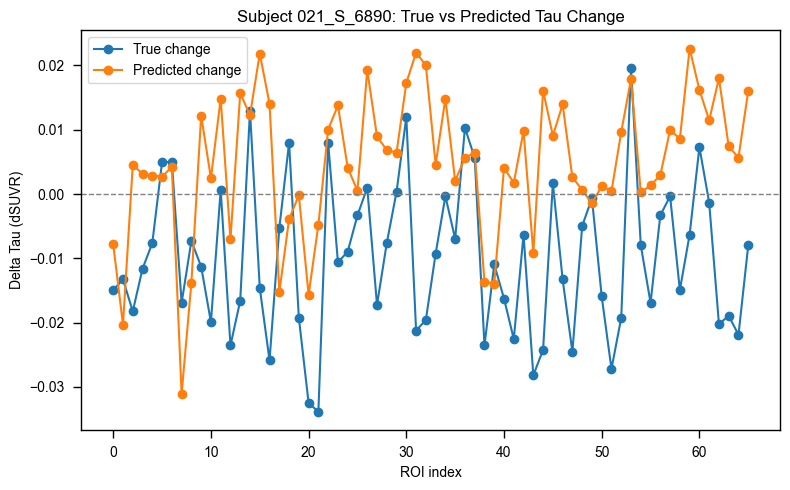

In [239]:
import numpy as np
import matplotlib.pyplot as plt

# Select one subject
row = regularizers_comparison.loc[0]

tau_tp1 = np.array(row["Tau tp1"], dtype=float)
tau_tp2 = np.array(row["Annualized Tau tp2"], dtype=float)
pred_no = np.array(row["esm"], dtype=float)

# Compute ground truth change
delta_true = tau_tp2 - tau_tp1

# Predicted change
delta_pred = pred_no - tau_tp1

# ROI indices
rois = np.arange(len(delta_true))

plt.figure(figsize=(8, 5))

plt.plot(rois, delta_true, marker='o', label='True change')
plt.plot(rois, delta_pred, marker='o', label='Predicted change')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel("ROI index")
plt.ylabel("Delta Tau (dSUVR)")
plt.title(f"Subject {row['Subject ID']}: True vs Predicted Tau Change")
plt.legend()
plt.tight_layout()
plt.show()


In [1445]:
### confusion matrices
## jack et al 3% inc in meta-ROI is "increasing tau"

In [1446]:
meta_rois_66 = pd.read_pickle('../data/66 ROIs processing/meta_rois_66.pkl')
meta_roi_indices = np.array(meta_rois_66.index)
meta_list = list(meta_roi_indices)

In [1447]:
maroon_cmap = LinearSegmentedColormap.from_list(
    "dark_maroon", ["#f4cccc", "#800000"], N=256  # light pink to deep maroon
)
def plot_and_save_cf(cf_percent, cf_counts, filename):
    plt.clf()
    fig, ax = plt.subplots()
    sns.heatmap(
        cf_percent,
        annot=False,
        cbar=False,
        vmin=0.0, vmax=100.0,
        cmap=maroon_cmap,
        ax=ax,
        linewidths=1,
        linecolor='white'
    )

    for i in range(cf_percent.shape[0]):
        for j in range(cf_percent.shape[1]):
            percent = f"{cf_percent[i, j]:.2f}%"
            count = f"({int(cf_counts[i, j])})"
            text_color = 'white' if cf_percent[i, j] > 50 else 'black'
            ax.text(j + 0.5, i + 0.35, percent, fontsize=30, ha='center', va='center', color=text_color)
            ax.text(j + 0.5, i + 0.70, count, fontsize=20, ha='center', va='center', color=text_color)

    ax.xaxis.set_ticklabels(['Non-increasing', 'Increasing'], size=15)
    ax.yaxis.set_ticklabels(['Non-increasing', 'Increasing'], size=15)
    ax.set_xlabel('Predicted', fontsize=20)
    ax.set_ylabel('True', fontsize=20)

    plt.tight_layout()
#     plt.savefig(f'../images/confusion_matrices/{folder}_{filename}.svg', bbox_inches='tight',
#                format = "svg")
    plt.show()


In [1448]:
inc_threshold = 0.03
eps = 1e-6

cfmat_dict = {}
percent_cfmat_dict = {}
for regularizer in regularizers:
    y_true, y_pred = [], []
    for el in range(len(regularizers_comparison)):
        tp1_suvr = np.array(regularizers_comparison['Tau tp1'][el][meta_list])
        tp2_suvr = np.array(regularizers_comparison['Annualized Tau tp2'][el][meta_list])
        pred_suvr = np.array(regularizers_comparison[regularizer][el][meta_list])
        
        frac_change_true = np.mean((tp2_suvr - tp1_suvr) / (tp1_suvr + eps))
        frac_change_pred = np.mean((pred_suvr - tp1_suvr) / (tp1_suvr + eps))
        true_inc = frac_change_true >= inc_threshold
        pred_inc = frac_change_pred >= inc_threshold
        
#         true_inc = (tp2_suvr.mean()/tp1_suvr.mean() - 1) >= inc_threshold
#         pred_inc = (pred_suvr.mean()/tp1_suvr.mean() - 1) >= inc_threshold
        y_true.append(int(true_inc))
        y_pred.append(int(pred_inc))
    cf = confusion_matrix(y_true, y_pred, labels=[False, True])
    cfmat_dict[regularizer] = cf
    percent_cf = 100 * cf / cf.sum(axis=1, keepdims=True)
    percent_cfmat_dict[regularizer] = percent_cf
    acc = np.trace(cf) / cf.sum()
    bal_acc = np.mean(np.diag(cf) / cf.sum(axis=1))

    print(f"{regularizer}: Acc={acc:.3f}, BalAcc={bal_acc:.3f}, CF={cf}")

no_reg: Acc=0.691, BalAcc=0.509, CF=[[80 17]
 [21  5]]
fkpp: Acc=0.789, BalAcc=0.500, CF=[[97  0]
 [26  0]]
esm: Acc=0.715, BalAcc=0.496, CF=[[85 12]
 [23  3]]


In [1449]:
cfmat_dict

{'no_reg': array([[80, 17],
        [21,  5]]),
 'fkpp': array([[97,  0],
        [26,  0]]),
 'esm': array([[85, 12],
        [23,  3]])}

In [1450]:
percent_cfmat_dict

{'no_reg': array([[82.4742268 , 17.5257732 ],
        [80.76923077, 19.23076923]]),
 'fkpp': array([[100.,   0.],
        [100.,   0.]]),
 'esm': array([[87.62886598, 12.37113402],
        [88.46153846, 11.53846154]])}

<Figure size 640x480 with 0 Axes>

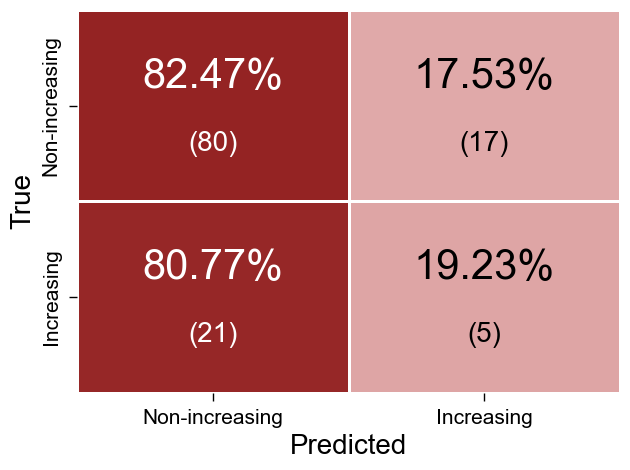

In [1451]:
reg = 'no_reg'
plot_and_save_cf(percent_cfmat_dict[reg], cfmat_dict[reg], reg)

In [1452]:
cf_df = pd.DataFrame(
    cf,
    index=["True Non-Inc", "True Inc"],
    columns=["Pred Non-Inc", "Pred Inc"]
)


In [1453]:
cf_df

,Pred Non-Inc,Pred Inc
True Non-Inc,85,12
True Inc,23,3


In [1454]:
cf_percent = 100 * cf / cf.sum(axis=1, keepdims=True)


In [1455]:
cf_percent

array([[87.62886598, 12.37113402],
       [88.46153846, 11.53846154]])

In [1456]:
print("True Inc fraction:", np.mean(y_true))
print("Pred Inc fraction:", np.mean(y_pred))


True Inc fraction: 0.21138211382113822
Pred Inc fraction: 0.12195121951219512


In [1457]:
from sklearn.metrics import roc_auc_score, roc_curve


In [1458]:
inc_threshold = 0.03
eps = 1e-6

auc_dict = {}

for regularizer in regularizers:
    y_true = []
    y_score = []   # continuous scores

    for el in range(len(regularizers_comparison)):
        tp1_suvr = np.array(regularizers_comparison['Tau tp1'][el][meta_list])
        tp2_suvr = np.array(regularizers_comparison['Annualized Tau tp2'][el][meta_list])
        pred_suvr = np.array(regularizers_comparison[regularizer][el][meta_list])

        frac_change_true = np.mean((tp2_suvr - tp1_suvr) / (tp1_suvr + eps))
        frac_change_pred = np.mean((pred_suvr - tp1_suvr) / (tp1_suvr + eps))

        y_true.append(int(frac_change_true >= inc_threshold))
        y_score.append(frac_change_pred)

    auc = roc_auc_score(y_true, y_score)
    auc_dict[regularizer] = auc

    print(f"{regularizer}: ROC-AUC = {auc:.3f}")


no_reg: ROC-AUC = 0.577
fkpp: ROC-AUC = 0.508
esm: ROC-AUC = 0.633


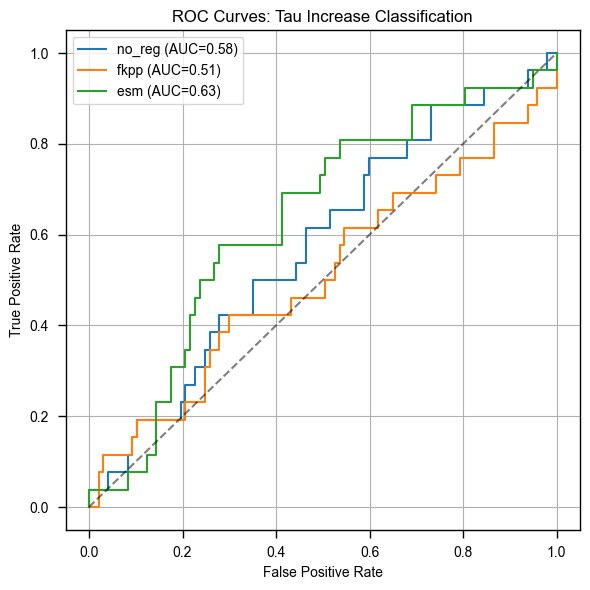

In [1459]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for regularizer in regularizers:
    y_true, y_score = [], []

    for el in range(len(regularizers_comparison)):
        tp1_suvr = np.array(regularizers_comparison['Tau tp1'][el][meta_list])
        tp2_suvr = np.array(regularizers_comparison['Annualized Tau tp2'][el][meta_list])
        pred_suvr = np.array(regularizers_comparison[regularizer][el][meta_list])

        frac_change_true = np.mean((tp2_suvr - tp1_suvr) / (tp1_suvr + eps))
        frac_change_pred = np.mean((pred_suvr - tp1_suvr) / (tp1_suvr + eps))

        y_true.append(int(frac_change_true >= inc_threshold))
        y_score.append(frac_change_pred)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.plot(fpr, tpr, label=f"{regularizer} (AUC={auc:.2f})")

plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Tau Increase Classification")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [2038]:
mean_meta = []
mean_all = []

for el in range(len(regularizers_comparison)):
    dsu_all = np.array(regularizers_comparison['Annualized Tau tp2'][el]) \
              - np.array(regularizers_comparison['Tau tp1'][el])

    dsu_meta = dsu_all[meta_list]

    mean_all.append(dsu_all.mean())
    mean_meta.append(dsu_meta.mean())

mean_all = np.array(mean_all)
mean_meta = np.array(mean_meta)

print(f"GT mean dSUVR (all ROIs):  {mean_all.mean():.4f} ± {mean_all.std():.4f}")
print(f"GT mean dSUVR (meta ROIs): {mean_meta.mean():.4f} ± {mean_meta.std():.4f}")


GT mean dSUVR (all ROIs):  0.0052 ± 0.0386
GT mean dSUVR (meta ROIs): 0.0130 ± 0.0556


In [2039]:
from scipy.stats import pearsonr, spearmanr

r_p, _ = pearsonr(mean_all, mean_meta)
r_s, _ = spearmanr(mean_all, mean_meta)

print(f"GT all vs meta correlation: Pearson r={r_p:.3f}, Spearman ρ={r_s:.3f}")


GT all vs meta correlation: Pearson r=0.900, Spearman ρ=0.919
